In [1]:

from itertools import islice

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.utils import make_grid

from maskvar.datasets.coco_lvis import LvisDataset
from maskvar.datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from maskvar.datasets.mask_level_dataset import MaskLevelDataset, MaskLevelDatasetRandom, MaskLevelDatasetDummy
from maskvar.datasets import instance_info
from maskvar.maskseg_build_everything import (
    build_hqseg44k_dataset,
    build_mobile_sam_image_encoder,
)

In [2]:
device = 'cuda:0'

In [3]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [5]:
# dataset = HQSeg44KTrainDataset(
#     data_root='../data/sam-hq',
#     img_size=(256, 256)
# )
# dataset = LvisDataset(
#     dataset_path='../data/coco_lvis',
#     split='train',
#     img_split='train',
#     stuff_prob=0.0,
# )

sam_image_encoder = build_mobile_sam_image_encoder('../ckpt/mobile_sam.pt').to(device)
sam_image_encoder = torch.compile(sam_image_encoder)

dataset, _ = build_hqseg44k_dataset('../data/sam-hq')

# mask_level_dataset = MaskLevelDatasetRandom(dataset, sam_encoder=None, with_image_embed=False, device=device, seed=42, infinite=True, mask_filter_thresh=0.2)
mask_level_dataset = MaskLevelDatasetDummy(
    dataset=dataset,
    sam_encoder=sam_image_encoder,
    with_image_embed=True,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
    count=5,
)

Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 1615068.10it/s]


torch.Size([25, 3, 256, 256]) torch.Size([25, 3, 256, 256])


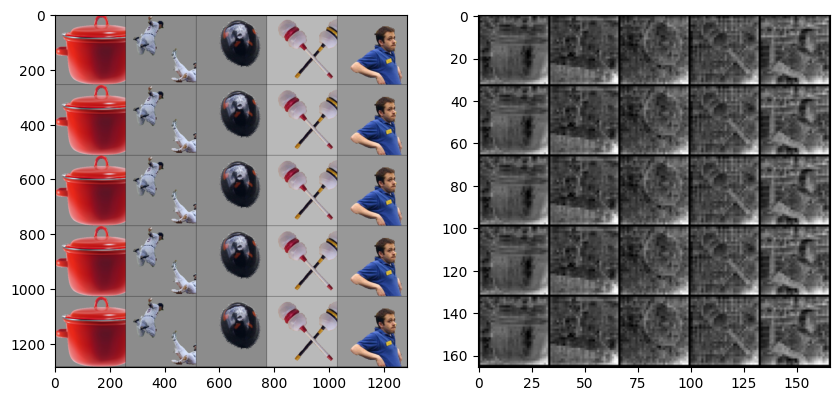

In [18]:
data_iter = iter(mask_level_dataset)

masks = []
images = []
feats_map = []
for i, data in enumerate(islice(data_iter, 25)):
    image, image_embed_sam, _, mask = data # (C=3, H, W) and (1, H, W)
    # expand mask from (C=1, H, W) to (C=3, H, W)
    mask = mask.expand(3, -1, -1)
    masks.append(mask)
    images.append(image)
    image_embed_sam = F.interpolate(image_embed_sam.unsqueeze(0), size=(32,32), mode='bilinear', align_corners=False)
    flat = torch.sum(image_embed_sam, dim=1)
    feats_map.append(flat)

images_tensor = torch.stack(images)
masks_tensor = torch.stack(masks)
feats_map = torch.stack(feats_map)

images_tensor = F.interpolate(images_tensor, size=(256, 256), mode='bilinear', align_corners=False)

print(images_tensor.shape, masks_tensor.shape)

vis_mask = images_tensor * masks_tensor + (1 - masks_tensor) * 0.5

chw = make_grid(vis_mask, nrow=5, padding=1, normalize=True, scale_each=True)
hwc = chw.permute(1, 2, 0).cpu().numpy()

chw_feats = make_grid(feats_map, nrow=5, padding=1, normalize=True, scale_each=True)
hwc_feats = chw_feats.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(hwc)
ax[1].imshow(hwc_feats)
plt.show()